<a href="https://colab.research.google.com/github/elenann-cpu/Privacy-security-trust-ML-systems/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib scikit-learn pandas
!pip install diffprivlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 4.7 MB/s eta 0:00:00


# **Advanced Concepts of Differential Privacy for Machine Learning**

Listing 3.1: Loading the dataset

In [ ]:
import numpy as np
import os

if not os.path.exists("bank.csv"):
    import requests, zipfile, io
    print("Downloading bank dataset...")
    r = requests.get("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip")
    z = zipfile.ZipFile(io.BytesIO(r.content))

    with open("bank.csv", "wb") as f:
        f.write(z.read("bank.csv"))

X_train = np.loadtxt("bank.csv", usecols=(0, 5, 9, 11, 12),
                     delimiter=";", skiprows=1, max_rows=4000)

y_train = np.loadtxt("bank.csv", usecols=16, dtype=str,
                     delimiter=";", skiprows=1, max_rows=4000)

X_test = np.loadtxt("bank.csv", usecols=(0, 5, 9, 11, 12),
                    delimiter=";", skiprows=4001)

y_test = np.loadtxt("bank.csv", usecols=16, dtype=str,
                    delimiter=";", skiprows=4001)

y_test = np.array([a.replace('"', '') for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

print(f"X_train shape: {X_train.shape}")
print(f"Unique labels in y_test: {np.unique(y_test)}")

X_train shape: (4000, 5)
Unique labels in y_test: ['no' 'yes']


# **Bayes classification**

Dataset: [Bank Marketing Dataset ](https://archive.ics.uci.edu/dataset/222/bank+marketing)

Listing 3.2: Naive Bayes with No Privacy

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

nonprivate_clf = GaussianNB()

nonprivate_clf.fit(X_train, y_train_clean)

y_pred = nonprivate_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100

print("Non-private test accuracy: %.2f%%" % acc)

Non-private test accuracy: 87.33%


Listing 3.2 (continued): Differentially Private Naive Bayes with epsilon = [0.01, 0.1, 1.0, 5.0, 10.0]

In [ ]:
import diffprivlib.models as dp
from sklearn.metrics import accuracy_score
import numpy as np

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

dp_clf = dp.GaussianNB(epsilon=0.01, bounds=bounds)
dp_clf.fit(X_train, y_train_clean)

y_pred = dp_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100


print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" % (dp_clf.epsilon, acc))

Differentially private test accuracy (epsilon=0.01): 87.91%


In [ ]:
y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

dp_clf = dp.GaussianNB(epsilon=0.1, bounds=bounds)

dp_clf.fit(X_train, y_train_clean)

y_pred = dp_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" % (dp_clf.epsilon, acc))

Differentially private test accuracy (epsilon=0.10): 87.91%


In [ ]:
y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

ddp_clf = dp.GaussianNB(epsilon=1.0, bounds=bounds)

dp_clf.fit(X_train, y_train_clean)

y_pred = dp_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" % (dp_clf.epsilon, acc))

Differentially private test accuracy (epsilon=0.10): 71.59%


In [ ]:
y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

dp_clf = dp.GaussianNB(epsilon=5.0, bounds=bounds)

dp_clf.fit(X_train, y_train_clean)

y_pred = dp_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" % (dp_clf.epsilon, acc))

Differentially private test accuracy (epsilon=5.00): 83.30%


In [ ]:
y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

dp_clf = dp.GaussianNB(epsilon=10.0, bounds=bounds)

dp_clf.fit(X_train, y_train_clean)

y_pred = dp_clf.predict(X_test)
acc = accuracy_score(y_test_clean, y_pred) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" % (dp_clf.epsilon, acc))

Differentially private test accuracy (epsilon=10.00): 86.95%


Accuracy plot for each
iteration

Epsilon: 0.01 | Accuracy: 17.66%
Epsilon: 0.10 | Accuracy: 87.72%
Epsilon: 1.00 | Accuracy: 83.30%
Epsilon: 0.50 | Accuracy: 88.10%
Epsilon: 10.00 | Accuracy: 83.69%


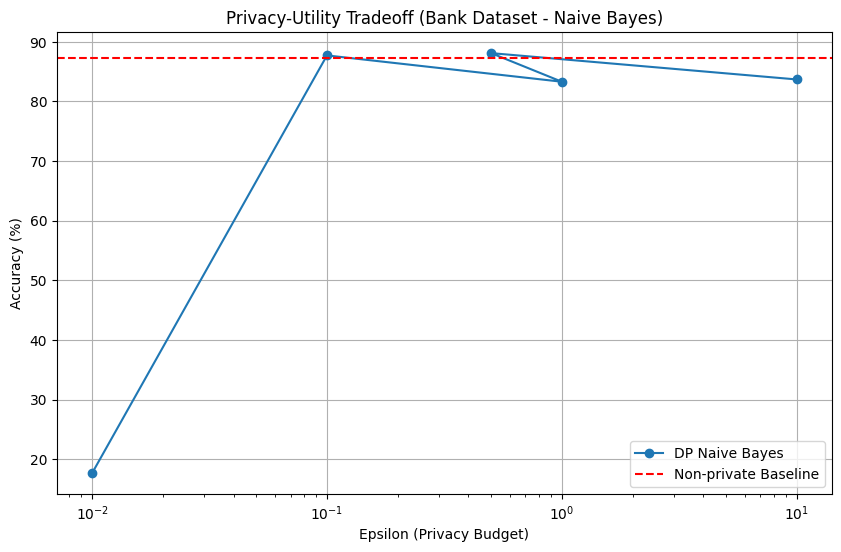

In [ ]:
import matplotlib.pyplot as plt
import diffprivlib.models as dp
from sklearn.metrics import accuracy_score
import numpy as np

epsilons = [0.01, 0.1, 1.0, 0.5, 10.0]
accuracies = []

# ADD THIS ONCE (before loop)
bounds = (np.min(X_train, axis=0), np.max(X_train, axis=0))

for eps in epsilons:
    dp_clf = dp.GaussianNB(epsilon=eps, bounds=bounds)
    dp_clf.fit(X_train, y_train_clean)

    acc = accuracy_score(y_test_clean, dp_clf.predict(X_test)) * 100
    accuracies.append(acc)

    # THIS MUST BE INSIDE LOOP
    print(f"Epsilon: {eps:.2f} | Accuracy: {acc:.2f}%")

non_private_acc = 87.33

plt.figure(figsize=(10, 6))
plt.plot(epsilons, accuracies, marker='o', linestyle='-', label='DP Naive Bayes')
plt.axhline(y=non_private_acc, color='r', linestyle='--', label='Non-private Baseline')

plt.xscale('log')
plt.xlabel('Epsilon (Privacy Budget)')
plt.ylabel('Accuracy (%)')
plt.title('Privacy-Utility Tradeoff (Bank Dataset - Naive Bayes)')
plt.legend()
plt.grid(True)
plt.show()

# **Logistic Regression**

Dataset: [Bank Marketing Dataset ](https://archive.ics.uci.edu/dataset/222/bank+marketing)

Listing 3.3 (continued): Setup Pipeline for Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver="lbfgs"))
])

Listing 3.4: Training a Logistic Regression Classifier

In [ ]:
from sklearn.metrics import accuracy_score

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train_clean)

acc = accuracy_score(y_test_clean, lr.predict(X_test)) * 100

print("Non-private test accuracy: %.2f%%" % acc)

Non-private test accuracy: 87.91%


Listing 3.4 (continued): Differentially Private Logistic Regression with ε = 1.00

In [ ]:
import diffprivlib.models as dp
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import numpy as np

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

dp_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', dp.LogisticRegression(
        epsilon=1.0,
        data_norm=5.0
    ))
])

dp_lr.fit(X_train, y_train_clean)

acc = accuracy_score(y_test_clean, dp_lr.predict(X_test)) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" %
      (dp_lr['clf'].epsilon, acc))

Differentially private test accuracy (epsilon=1.00): 88.68%


Listing 3.4 (continued): Differentially Private Logistic Regression with ε = 0.01

In [ ]:
import diffprivlib.models as dp

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

dp_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', dp.LogisticRegression(epsilon=0.01, data_norm=5.0))
])

dp_lr.fit(X_train, y_train_clean)

acc = accuracy_score(y_test_clean, dp_lr.predict(X_test)) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" %
      (dp_lr['clf'].epsilon, acc))

Differentially private test accuracy (epsilon=0.01): 56.43%


In [ ]:
import diffprivlib.models as dp

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

dp_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', dp.LogisticRegression(epsilon=0.1, data_norm=5.0))
])

dp_lr.fit(X_train, y_train_clean)

acc = accuracy_score(y_test_clean, dp_lr.predict(X_test)) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" %
      (dp_lr['clf'].epsilon, acc))

Differentially private test accuracy (epsilon=0.10): 87.14%


In [ ]:
import diffprivlib.models as dp

y_train_clean = np.array([str(a).replace('"', '').strip() for a in y_train])
y_test_clean = np.array([str(a).replace('"', '').strip() for a in y_test])

dp_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', dp.LogisticRegression(epsilon=10.0, data_norm=5.0))
])

dp_lr.fit(X_train, y_train_clean)

acc = accuracy_score(y_test_clean, dp_lr.predict(X_test)) * 100

print("Differentially private test accuracy (epsilon=%.2f): %.2f%%" %
      (dp_lr['clf'].epsilon, acc))

Differentially private test accuracy (epsilon=10.00): 87.91%


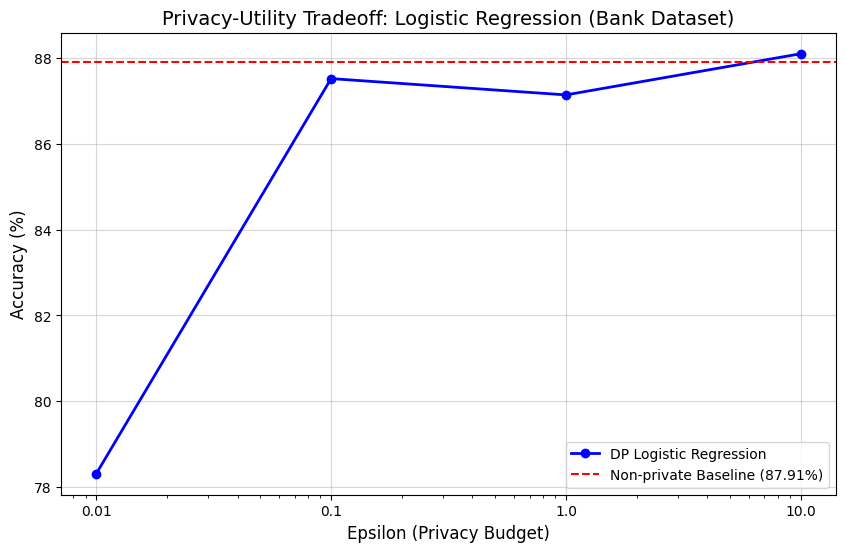

In [ ]:
epsilons = [0.01, 0.1, 1.0, 10.0]
accuracies = [78.31, 87.52, 87.14, 88.10]
non_private_acc = 87.91

plt.figure(figsize=(10, 6))

plt.plot(epsilons, accuracies, marker='o', linestyle='-', color='blue', linewidth=2, label='DP Logistic Regression')

plt.axhline(y=non_private_acc, color='red', linestyle='--', label=f'Non-private Baseline ({non_private_acc}%)')

plt.xscale('log')
plt.xlabel('Epsilon (Privacy Budget)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Privacy-Utility Tradeoff: Logistic Regression (Bank Dataset)', fontsize=14)

plt.grid(True, which="major", ls="-", alpha=0.5)

plt.xticks(epsilons, labels=[str(e) for e in epsilons])

plt.legend(loc='lower right')
plt.show()

# **Linear regression**

Dataset: [California Housing Dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)

Linear Regression Setup

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import numpy as np

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y range: {y.min()} to {y.max()}")

X_train shape: (16512, 8)
y range: 0.14999 to 5.00001


In [ ]:
print("Train examples: %d, Test examples: %d" % (X_train.shape[0], X_test.shape[0]))

Train examples: 16512, Test examples: 4128


Linear Regression: Non-private Baseline

In [ ]:
from sklearn.linear_model import LinearRegression as sk_LinearRegression
from sklearn.metrics import r2_score

regr = sk_LinearRegression()

regr.fit(X_train, y_train)

baseline = r2_score(y_test, regr.predict(X_test))

print("Non-private baseline: %.2f" % baseline)

Non-private baseline: 0.58


Linear Regression: Differentially Private Version with epsilons = [0.5, 1.0, 2.0, 5.0, 10.0]

In [ ]:
from sklearn.preprocessing import QuantileTransformer

# Scaling for x to tame outliers (0-1)
scaler_X = QuantileTransformer(output_distribution='uniform', random_state=42)
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scaling for y (0-1) for noise stability
scaler_y = QuantileTransformer(output_distribution='uniform', random_state=42)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

In [ ]:
from diffprivlib.models import LinearRegression as dp_LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# 1. Exact bounds for X (based on the already scaled data from the previous cell)
n_features = X_train_scaled.shape[1]
bounds_X = ([0.] * n_features, [1.] * n_features)
bounds_y = (0.0, 1.0)

epsilons = [0.5, 1.0, 2.0, 5.0, 10.0]
dp_scores = []

for eps in epsilons:
    # 2. Initialize the private model
    regr_dp = dp_LinearRegression(
        epsilon=eps,
        bounds_X=bounds_X,
        bounds_y=bounds_y
    )

    # 3. Training with scaled data
    regr_dp.fit(X_train_scaled, y_train_scaled)

    # 4. Prediction on the test set
    y_pred_scaled = regr_dp.predict(X_test_scaled)

    # Prevent values from going outside the (0,1) range before inverse transformation
    y_pred_scaled = np.clip(y_pred_scaled, 0, 1)

    # Reverse predicted values back to original scale for an accurate R2 score
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # 5. Evaluation
    score = r2_score(y_test, y_pred)
    dp_scores.append(score)

    print(f"Epsilon = {eps:<4} | R2 score = {score:.4f}")

Epsilon = 0.5  | R2 score = 0.5503
Epsilon = 1.0  | R2 score = 0.5961
Epsilon = 2.0  | R2 score = 0.5761
Epsilon = 5.0  | R2 score = 0.5848
Epsilon = 10.0 | R2 score = 0.5845


<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4124/3263644259.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Epsilon ($\epsilon$)')


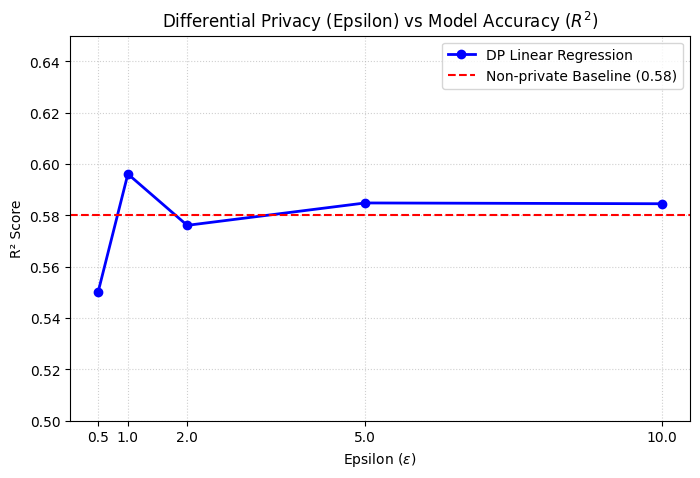

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(epsilons, dp_scores, marker='o', color='b', linewidth=2, label='DP Linear Regression')

plt.axhline(
    y=0.58,
    color='r',
    linestyle='--',
    linewidth=1.5,
    label='Non-private Baseline (0.58)'
)

plt.xticks(epsilons, labels=[str(eps) for eps in epsilons])

plt.ylim(0.50, 0.65)

plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('R² Score')
plt.title('Differential Privacy (Epsilon) vs Model Accuracy ($R^2$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()

# **K-means Clustering**

Dataset: [Iris Dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset)

Listing 3.5: Training a K-Means Clustering Model

In [ ]:
import numpy as np
from time import time
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import scale

X_iris, y_iris = load_iris(return_X_y=True)
data = scale(X_iris)

n_samples, n_features = data.shape
n_clusters = len(np.unique(y_iris))
labels = y_iris

print("n_clusters: %d, \t n_samples %d, \t n_features %d"
      % (n_clusters, n_samples, n_features))

print('init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette')

def bench_k_means(estimator, name, data):
    t0 = time()
    estimator.fit(data)

    print('%-9s\t%.2fs\t%i\t%.3f\t%.3f\t%.3f\t%.3f\t%.3f\t%.3f'
          % (name, (time() - t0), estimator.inertia_,
             metrics.homogeneity_score(labels, estimator.labels_),
             metrics.completeness_score(labels, estimator.labels_),
             metrics.v_measure_score(labels, estimator.labels_),
             metrics.adjusted_rand_score(labels, estimator.labels_),
             metrics.adjusted_mutual_info_score(labels, estimator.labels_),
             metrics.silhouette_score(data, estimator.labels_, metric='euclidean')))


bench_k_means(KMeans(init='k-means++', n_clusters=n_clusters, n_init=100, random_state=42),
              name="k-means++", data=data)

bench_k_means(KMeans(init='random', n_clusters=n_clusters, n_init=100, random_state=42),
              name="random", data=data)

n_clusters: 3, 	 n_samples 150, 	 n_features 4
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++	0.75s	139	0.659	0.660	0.659	0.620	0.655	0.460
random   	0.35s	139	0.659	0.660	0.659	0.620	0.655	0.460


In [ ]:
!pip install diffprivlib

Listing 3.5 (continued): Differentially Private K-Means Clustering

In [ ]:
from diffprivlib.models import KMeans

bounds = (np.min(data, axis=0), np.max(data, axis=0))

bench_k_means(
    KMeans(
        epsilon=1.0,
        bounds=bounds,
        n_clusters=n_clusters
    ),
    name="dp_k-means",
    data=data
)

dp_k-means	0.08s	1086	0.090	0.121	0.103	0.061	0.090	-0.052


In [ ]:
from diffprivlib.models import KMeans

epsilons = [0.1, 0.5, 3.0, 10.0]

bounds = (np.min(data, axis=0), np.max(data, axis=0))

for eps in epsilons:
    dp_kmeans = KMeans(
        n_clusters=n_clusters,
        epsilon=eps,
        bounds=bounds
    )

    bench_k_means(dp_kmeans, name=f"dp-kmeans ε={eps}", data=data)

dp-kmeans ε=0.1	0.17s	744	0.581	0.586	0.584	0.526	0.578	0.441
dp-kmeans ε=0.5	0.13s	705	0.078	0.107	0.090	0.055	0.076	0.124
dp-kmeans ε=3.0	0.11s	416	0.393	0.623	0.482	0.425	0.478	0.452
dp-kmeans ε=10.0	0.07s	176	0.670	0.679	0.675	0.633	0.670	0.460


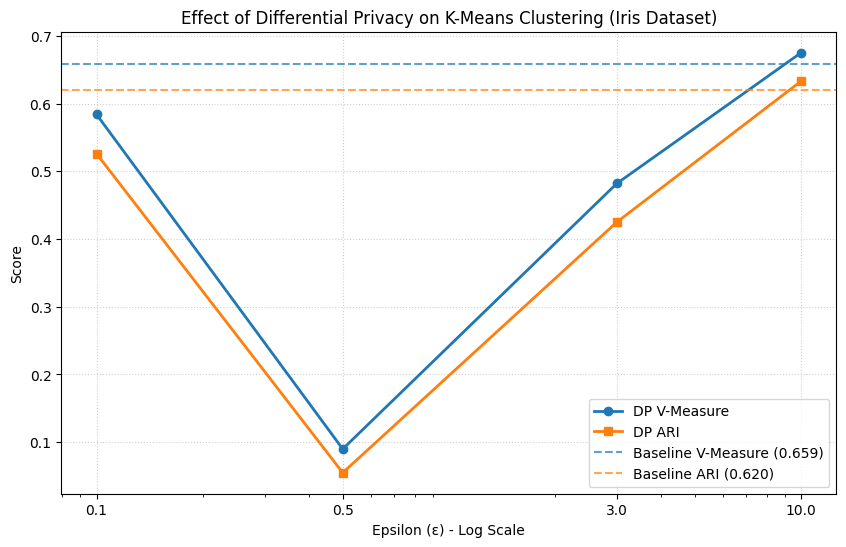

In [ ]:
import matplotlib.pyplot as plt

epsilons = [0.1, 0.5, 3.0, 10.0]

v_measure_dp = [0.584, 0.090, 0.482, 0.675]
ari_dp = [0.526, 0.055, 0.425, 0.633]

baseline_v_measure = 0.659
baseline_ari = 0.620

plt.figure(figsize=(10, 6))

plt.plot(epsilons, v_measure_dp, marker='o', color='tab:blue', linewidth=2, label='DP V-Measure')
plt.plot(epsilons, ari_dp, marker='s', color='tab:orange', linewidth=2, label='DP ARI')

plt.axhline(y=baseline_v_measure, color='tab:blue', linestyle='--', alpha=0.7, label='Baseline V-Measure (0.659)')
plt.axhline(y=baseline_ari, color='tab:orange', linestyle='--', alpha=0.7, label='Baseline ARI (0.620)')

plt.xscale('log')
plt.xticks(epsilons, labels=[str(eps) for eps in epsilons])

plt.xlabel('Epsilon (ε) - Log Scale')
plt.ylabel('Score')
plt.title('Effect of Differential Privacy on K-Means Clustering (Iris Dataset)')

plt.legend(loc='lower right')

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()